In [ ]:
import string
import numpy as np
from PIL import Image
import os
from pickle import dump, load
import numpy as np


from keras.preprocessing.image import load_img, img_to_array
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from tensorflow.keras.layers import add
from keras.models import Model, load_model
from keras.layers import Input, Dense, LSTM, Embedding, Dropout
from transformers import ViTFeatureExtractor, ViTModel
import torch
import sys
import os
import augment_images
from augment_images import main
import importlib

from tqdm.notebook import tqdm


## Flickr - 8 k Data set

In [2]:
dataset_text = "dataset/Flickr8k_text"
dataset_images = "dataset/Flicker8k_Dataset"

from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')


Your GPU may run slowly with dtype policy mixed_float16 because it does not have compute capability of at least 7.0. Your GPU:
  METAL, no compute capability (probably not an Nvidia GPU)
See https://developer.nvidia.com/cuda-gpus for a list of GPUs and their compute capabilities.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once


## Image Augmentation
#### Inorder to introduce variation in the dataset and improve training. Performing image augmentation.
#### Only the training set images are being augmented and augmentation logs are saved

In [ ]:
importlib.reload(augment_images)

# # Call it
flag = True
res = main(flag)
if flag:
    if res:
        print("Augmentation success:", res)
    else:
        print("Augmentation failed:", res)
else:
    print("No augmentation performed.")



## Preparing the data

In [ ]:
def load_doc(filename):
    file = open(filename, 'r')
    text = file.read()
    file.close()
    return text

def all_img_captions(filename):
    file = load_doc(filename)
    captions = file.split('\n')
    descriptions = {}
    for caption in captions[:-1]:
        img, caption = caption.split('\t')
        if img[:-2] not in descriptions:
            descriptions[img[:-2]] = [caption]
        else:
            descriptions[img[:-2]].append(caption)
    return descriptions

def cleaning_text(captions):
    table = str.maketrans('', '', string.punctuation)
    for img, caps in captions.items():
        for i, img_caption in enumerate(caps):
            img_caption.replace("-", " ")
            desc = img_caption.split()
            desc = [word.lower() for word in desc]
            desc = [word.translate(table) for word in desc]
            desc = [word for word in desc if len(word) > 1]
            desc = [word for word in desc if word.isalpha()]
            img_caption = ' '.join(desc)
            captions[img][i] = img_caption
    return captions

def text_vocabulary(descriptions):
    vocab = set()
    for key in descriptions.keys():
        [vocab.update(d.split()) for d in descriptions[key]]
    return vocab

def save_descriptions(descriptions, filename):
    lines = list()
    for key, desc_list in descriptions.items():
        for desc in desc_list:
            lines.append(key + '\t' + desc)
    data = "\n".join(lines)
    file = open(filename, "w")
    file.write(data)
    file.close()


In [ ]:
filename = dataset_text + "/" + "Flickr8k.token.txt"
descriptions = all_img_captions(filename)
print("Length of descriptions =", len(descriptions))

clean_descriptions = cleaning_text(descriptions)

vocabulary = text_vocabulary(clean_descriptions)
print("Length of vocabulary =", len(vocabulary))

save_descriptions(clean_descriptions, "descriptions.txt")


Length of descriptions = 20092
Length of vocabulary =  8763


## Feature Extraction using Vit Encoder

In [ ]:
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

def extract_features_vit(directory):
    features = {}
    for img_name in tqdm(os.listdir(directory)):
        path = os.path.join(directory, img_name)
        image = Image.open(path).convert("RGB")
        inputs = feature_extractor(images=image, return_tensors="pt")
        with torch.no_grad():
            outputs = vit_model(**inputs)
        pooled_features = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
        features[img_name] = pooled_features
    return features


/Users/abhinandanvijan/anaconda3/lib/python3.11/site-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


In [ ]:
# dont run everytime   uncomment later 
# 768 feature vector for ViT
features = extract_features_vit(dataset_images)
dump(features, open("features.p","wb"))



In [ ]:
def load_photos(filename):
    file = load_doc(filename)
    photos = file.split("\n")[:-1]
    return photos

def load_clean_descriptions(filename, photos): 
    file = load_doc(filename)
    descriptions = {}
    for line in file.split("\n"):
        words = line.split()
        if len(words) < 1:
            continue
        image, image_caption = words[0], words[1:]
        if image in photos:
            if image not in descriptions:
                descriptions[image] = []
            desc = '<start> ' + " ".join(image_caption) + ' <end>'
            descriptions[image].append(desc)
    return descriptions

def load_features(photos):
    all_features = load(open("features.p", "rb"))
    features = {k: all_features[k] for k in photos}
    return features

filename = dataset_text + "/" + "Flickr_8k.trainImages.txt"
train_imgs = load_photos(filename)
train_descriptions = load_clean_descriptions("descriptions.txt", train_imgs)
train_features = load_features(train_imgs)

print("train_descriptions = ", train_descriptions['1000268201_693b08cb0e.jpg'])


train_descriptions =  ['<start> child in pink dress is climbing up set of stairs in an entry way <end>', '<start> girl going into wooden building <end>', '<start> little girl climbing into wooden playhouse <end>', '<start> little girl climbing the stairs to her playhouse <end>', '<start> little girl in pink dress going into wooden cabin <end>']


In [ ]:
def dict_to_list(descriptions):
    all_desc = []
    for key in descriptions.keys():
        [all_desc.append(d) for d in descriptions[key]]
    return all_desc

from keras.preprocessing.text import Tokenizer

def create_tokenizer(descriptions):
    desc_list = dict_to_list(descriptions)
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(desc_list)
    return tokenizer


In [ ]:

tokenizer = create_tokenizer(train_descriptions)
dump(tokenizer, open('tokenizer.p', 'wb'))
vocab_size = len(tokenizer.word_index) + 1
vocab_size

print(tokenizer.word_index)


{'end': 1, 'start': 2, 'in': 3, 'the': 4, 'on': 5, 'is': 6, 'and': 7, 'dog': 8, 'with': 9, 'man': 10, 'of': 11, 'two': 12, 'white': 13, 'black': 14, 'boy': 15, 'are': 16, 'woman': 17, 'girl': 18, 'to': 19, 'wearing': 20, 'at': 21, 'people': 22, 'water': 23, 'brown': 24, 'young': 25, 'red': 26, 'an': 27, 'his': 28, 'blue': 29, 'dogs': 30, 'running': 31, 'through': 32, 'playing': 33, 'while': 34, 'down': 35, 'shirt': 36, 'ball': 37, 'standing': 38, 'little': 39, 'grass': 40, 'snow': 41, 'child': 42, 'person': 43, 'jumping': 44, 'over': 45, 'three': 46, 'sitting': 47, 'front': 48, 'field': 49, 'holding': 50, 'small': 51, 'yellow': 52, 'green': 53, 'group': 54, 'up': 55, 'by': 56, 'large': 57, 'one': 58, 'walking': 59, 'her': 60, 'men': 61, 'children': 62, 'air': 63, 'into': 64, 'near': 65, 'mouth': 66, 'beach': 67, 'jumps': 68, 'runs': 69, 'another': 70, 'for': 71, 'street': 72, 'from': 73, 'its': 74, 'riding': 75, 'stands': 76, 'bike': 77, 'girls': 78, 'as': 79, 'outside': 80, 'play': 81

In [ ]:

def max_length(descriptions):
    desc_list = dict_to_list(descriptions)
    return max(len(d.split()) for d in desc_list)
    
max_length = max_length(descriptions)
max_length

32

### Data Generator

In [ ]:
from keras.utils import to_categorical
import numpy as np

features = load(open("features.p", "rb"))

def create_sequences(tokenizer, max_length, descriptions, photos, vocab_size):
    X1, X2, y = [], [], []

    for key, desc_list in descriptions.items():
        if key not in photos:
            continue
        for desc in desc_list:
            seq = tokenizer.texts_to_sequences([desc])[0]

            for i in range(1, len(seq)):
                input_seq = seq[:i]
                output_seq = seq[1:i+1]

                input_seq = pad_sequences([input_seq], maxlen=max_length, padding='post')[0]
                output_seq = pad_sequences([output_seq], maxlen=max_length, padding='post')[0]

                X1.append(photos[key])
                X2.append(input_seq)
                y.append(output_seq)

    return np.array(X1), np.array(X2), np.array(y)


### Image Captioning Model (Encoder-Decoder Architecture)  

In [ ]:
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras import regularizers

class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pos_encoding = self._positional_encoding(max_len, d_model)

    def _positional_encoding(self, max_len, d_model):
        pos = tf.cast(tf.range(max_len)[:, tf.newaxis], tf.float32)
        i = tf.cast(tf.range(d_model)[tf.newaxis, :], tf.float32)
        angle_rates = 1 / tf.pow(10000.0, (2 * (i // 2)) / d_model)
        angle_rads = pos * angle_rates
        sines = tf.sin(angle_rads[:, 0::2])
        cosines = tf.cos(angle_rads[:, 1::2])
        pos_encoding = tf.concat([sines, cosines], axis=-1)
        pos_encoding = pos_encoding[tf.newaxis, ...]
        return tf.cast(pos_encoding, tf.float32)

    def call(self, x):
        pos_encoding = tf.cast(self.pos_encoding, x.dtype)
        return x + pos_encoding[:, :tf.shape(x)[1], :]

def transformer_decoder_block(embed_dim, num_heads, ff_dim, dropout=0.1):
    inputs = Input(shape=(None, embed_dim))
    enc_outputs = Input(shape=(None, embed_dim))

    self_attn = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(inputs, inputs)
    self_attn = Dropout(dropout)(self_attn)
    self_attn = Add()([inputs, self_attn])
    self_attn = LayerNormalization()(self_attn)

    cross_attn = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(self_attn, enc_outputs)
    cross_attn = Dropout(dropout)(cross_attn)
    cross_attn = Add()([self_attn, cross_attn])
    cross_attn = LayerNormalization()(cross_attn)

    ff = Dense(ff_dim, activation='relu', kernel_regularizer=regularizers.l2(0.001))(cross_attn)
    ff = Dense(embed_dim, kernel_regularizer=regularizers.l2(0.001))(ff)
    ff = Dropout(dropout)(ff)
    ff = Add()([cross_attn, ff])
    ff = LayerNormalization()(ff)

    return Model(inputs=[inputs, enc_outputs], outputs=ff)

def define_transformer_decoder(vocab_size, max_length, embed_dim=256, ff_dim=512, num_heads=4):
    image_input = Input(shape=(768,))
    caption_input = Input(shape=(max_length,))

    img_emb = Dense(embed_dim, kernel_regularizer=regularizers.l2(0.001))(image_input)
    img_emb = tf.expand_dims(img_emb, 1)
    img_emb = tf.repeat(img_emb, max_length, axis=1)

    caption_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True)(caption_input)
    caption_emb = PositionalEncoding(max_length, embed_dim)(caption_emb)

    decoder = transformer_decoder_block(embed_dim, num_heads, ff_dim)([caption_emb, img_emb])

    outputs = Dense(vocab_size, activation='softmax', dtype='float32')(decoder)

    model = Model(inputs=[image_input, caption_input], outputs=outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    return model

model = define_transformer_decoder(vocab_size, max_length)
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 768)]                0         []                            
                                                                                                  
 input_4 (InputLayer)        [(None, 32)]                 0         []                            
                                                                                                  
 dense_1 (Dense)             (None, 256)                  196864    ['input_3[0][0]']             
                                                                                                  
 embedding_1 (Embedding)     (None, 32, 256)              1939712   ['input_4[0][0]']             
                                                                                            

### Training the Image Captioning Model  

In [ ]:
print('Dataset: ', len(train_imgs))
print('Descriptions: train=', len(train_descriptions))
print('Photos: train=', len(train_features))
print('Vocabulary Size:', vocab_size)
print('Description Length: ', max_length)

X1train, X2train, ytrain = create_sequences(tokenizer, max_length, train_descriptions, train_features, vocab_size)

validn_imgs = load_photos("dataset/Flickr8k_text/Flickr_8k.devImages.txt")
dev_descriptions = load_clean_descriptions("descriptions.txt", validn_imgs)
dev_features = load_features(validn_imgs)
X1val, X2val, yval = create_sequences(tokenizer, max_length, dev_descriptions, dev_features, vocab_size)

model = load_model("vit_transformer_best.h5", custom_objects={"PositionalEncoding": PositionalEncoding})

from tensorflow.keras import backend as K
K.set_value(model.optimizer.learning_rate, 0.0005)
model.compile(optimizer=model.optimizer, loss='sparse_categorical_crossentropy')
print(f"New learning rate: {model.optimizer.learning_rate.numpy()}")

from keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("vit_transformer_best.h5", monitor='val_loss', save_best_only=True)

history = model.fit(
    [X1train, X2train], ytrain,
    validation_data=([X1val, X2val], yval),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Dataset:  18000
Descriptions: train= 18000
Photos: train= 18000
Vocabulary Size: 7577
Description Length:  32
New learning rate: 0.0005000000237487257
Epoch 1/20


2025-04-26 01:29:06.759031: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


14363/14363 [==============================] - ETA: 0s - loss: 0.0922

2025-04-26 01:56:13.459891: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


14363/14363 [==============================] - 1670s 116ms/step - loss: 0.0922 - val_loss: 0.1246
Epoch 2/20


/Users/abhinandanvijan/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


14363/14363 [==============================] - 1694s 118ms/step - loss: 0.0885 - val_loss: 0.1275
Epoch 3/20
14363/14363 [==============================] - 1669s 116ms/step - loss: 0.0861 - val_loss: 0.1273
Epoch 4/20
14363/14363 [==============================] - 1709s 119ms/step - loss: 0.0841 - val_loss: 0.1284
Epoch 5/20
14363/14363 [==============================] - 1666s 116ms/step - loss: 0.0824 - val_loss: 0.1306
Epoch 6/20
14363/14363 [==============================] - 1667s 116ms/step - loss: 0.0809 - val_loss: 0.1321


### Generating captions from image features using the trained model.  
#### Evaluates generated captions against ground-truth descriptions using BLEU-1 to BLEU-4 and METEOR scores.  
#### Performs evaluation on the test set (Flickr8k) using extracted features and cleaned descriptions.


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import argparse
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from tensorflow.keras.models import load_model

def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_caption_from_features(model, tokenizer, photo, max_length):
    in_text = 'start'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')
        preds = model.predict([photo, sequence], verbose=0)
        next_token = np.argmax(preds[0, i])
        word = word_for_id(next_token, tokenizer)
        if word is None or word == 'end':
            break
        in_text += ' ' + word
    return in_text.replace('start', '').replace('end', '').strip()

def evaluate_model(model, descriptions, photos, tokenizer, max_length):
    smooth = SmoothingFunction().method4
    actual, predicted = [], []
    scores = []

    for key, desc_list in tqdm(descriptions.items()):
        if key not in photos:
            continue
        yhat = generate_caption_from_features(model, tokenizer, photos[key].reshape(1, 768), max_length)
        references = [d.split() for d in desc_list]
        candidate = yhat.split()
        actual.append(references)
        predicted.append(candidate)

        bleu1 = sentence_bleu(references, candidate, weights=(1.0, 0, 0, 0), smoothing_function=smooth)
        bleu2 = sentence_bleu(references, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
        bleu3 = sentence_bleu(references, candidate, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
        bleu4 = sentence_bleu(references, candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
        meteor = meteor_score(references, candidate)

        scores.append((key, yhat, bleu1, bleu2, bleu3, bleu4, meteor))

    return scores

test_imgs = load_photos(dataset_text + "/Flickr_8k.testImages.txt")
test_descriptions = load_clean_descriptions("descriptions.txt", test_imgs)
test_features = load_features(test_imgs)

model = load_model("vit_transformer_best.h5", custom_objects={"PositionalEncoding": PositionalEncoding})
results = evaluate_model(model, test_descriptions, test_features, tokenizer, max_length)

def summarize_scores(results):
    bleu1_scores = [r[2] for r in results]
    bleu2_scores = [r[3] for r in results]
    bleu3_scores = [r[4] for r in results]
    bleu4_scores = [r[5] for r in results]
    meteor_scores = [r[6] for r in results]

    print("Average BLEU-1: {:.4f}".format(np.mean(bleu1_scores)))
    print("Average BLEU-2: {:.4f}".format(np.mean(bleu2_scores)))
    print("Average BLEU-3: {:.4f}".format(np.mean(bleu3_scores)))
    print("Average BLEU-4: {:.4f}".format(np.mean(bleu4_scores)))
    print("Average METEOR: {:.4f}".format(np.mean(meteor_scores)))

summarize_scores(results)
print("\n")


  0%|          | 0/1000 [00:00<?, ?it/s]

2025-04-26 09:48:18.713801: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Average BLEU-1: 0.4334
Average BLEU-2: 0.2459
Average BLEU-3: 0.1485
Average BLEU-4: 0.0944
Average METEOR: 0.2461




In [ ]:
def generate_caption_beam(model, tokenizer, photo, max_length, beam_width=3, start_token='start', end_token='end'):
    sequences = [[[tokenizer.word_index[start_token]], 0.0, []]]
    vocab_size = len(tokenizer.word_index) + 1

    for _ in range(max_length):
        all_candidates = []
        for seq, score, words in sequences:
            if len(words) > 0 and words[-1] == end_token:
                all_candidates.append((seq, score, words))
                continue

            padded_seq = pad_sequences([seq], maxlen=max_length, padding='post')
            preds = model.predict([photo, padded_seq], verbose=0)
            preds = preds[0][len(seq)-1]

            top_indices = np.argsort(preds)[-beam_width:]
            for idx in top_indices:
                word = word_for_id(idx, tokenizer)
                if word is None:
                    continue
                new_seq = seq + [idx]
                new_score = score - np.log(preds[idx] + 1e-9)
                new_words = words + [word]
                all_candidates.append((new_seq, new_score, new_words))

        ordered = sorted(all_candidates, key=lambda tup: tup[1])
        sequences = ordered[:beam_width]

    best_seq = sequences[0][2]
    caption = ' '.join([w for w in best_seq if w not in [start_token, end_token]])
    return caption.strip()

def evaluate_model(model, descriptions, photos, tokenizer, max_length):
    smooth = SmoothingFunction().method4
    actual, predicted = [], []
    scores = []

    for key, desc_list in tqdm(descriptions.items()):
        if key not in photos:
            continue
        yhat = generate_caption_beam(model, tokenizer, photos[key].reshape(1, 768), max_length, 3)
        references = [d.split() for d in desc_list]
        candidate = yhat.split()
        actual.append(references)
        predicted.append(candidate)

        bleu1 = sentence_bleu(references, candidate, weights=(1.0, 0, 0, 0), smoothing_function=smooth)
        bleu2 = sentence_bleu(references, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
        bleu3 = sentence_bleu(references, candidate, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
        bleu4 = sentence_bleu(references, candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
        meteor = meteor_score(references, candidate)

        scores.append((key, yhat, bleu1, bleu2, bleu3, bleu4, meteor))
    
    return scores

test_imgs = load_photos(dataset_text + "/Flickr_8k.testImages.txt")
test_descriptions = load_clean_descriptions("descriptions.txt", test_imgs)
test_features = load_features(test_imgs)



model = load_model("vit_transformer_best.h5", custom_objects={"PositionalEncoding": PositionalEncoding})
results = evaluate_model(model, test_descriptions, test_features, tokenizer, max_length)


  0%|          | 0/1000 [00:00<?, ?it/s]

2025-04-26 11:04:58.686252: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


In [53]:
def display_image(image_path):
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

print("Results for beam search",len(results))

Results for beam search 1000


Average BLEU-1: 0.4379
Average BLEU-2: 0.2611
Average BLEU-3: 0.1631
Average BLEU-4: 0.1067
Average METEOR: 0.2504


 Top 5 Captions by BLEU-4:

Image: 3363750526_efcedc47a9.jpg
Caption: black and white dog is running in field
BLEU-4: 0.8409


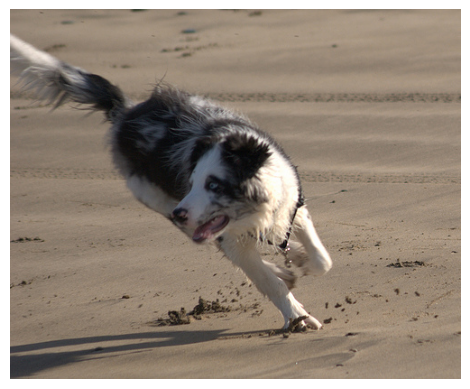

Image: 115684808_cb01227802.jpg
Caption: two people are standing in the snow
BLEU-4: 0.8091


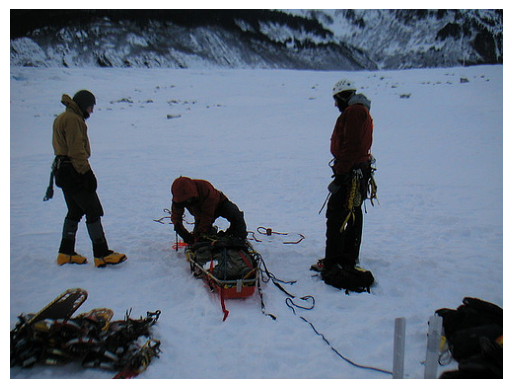

Image: 3058439373_9276a4702a.jpg
Caption: group of people are standing in front of building
BLEU-4: 0.7726


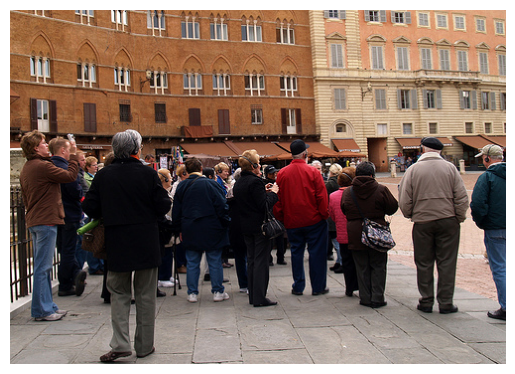

Image: 3071676551_a65741e372.jpg
Caption: the surfer is riding wave
BLEU-4: 0.7071


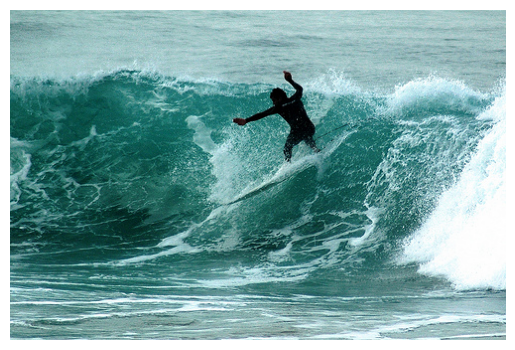

Image: 3630641436_8f9ac5b9b2.jpg
Caption: two dogs are running in the surf
BLEU-4: 0.6804


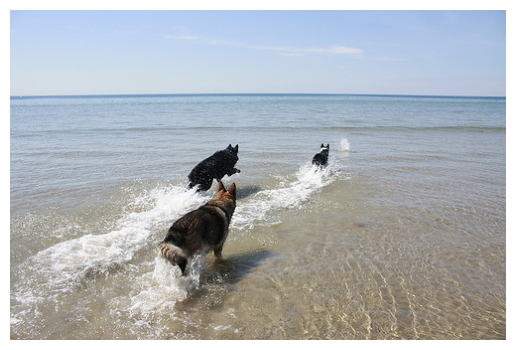


 Bottom 5 Captions by BLEU-4:

Image: 180506881_de0f59770f.jpg
Caption: man in black shirt is skateboarding
BLEU-4: 0.0000


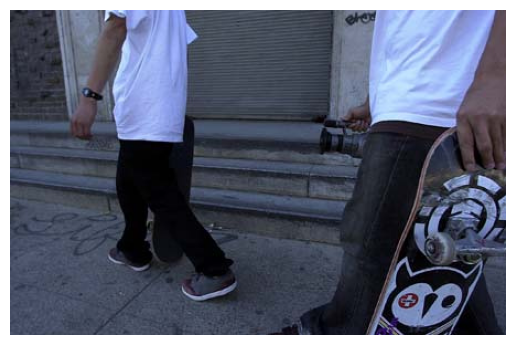

Image: 2229179070_dc8ea8582e.jpg
Caption: the baseball player in the grass
BLEU-4: 0.0000


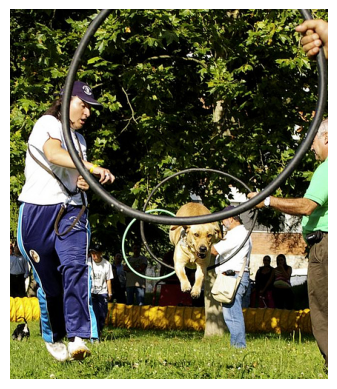

Image: 2475162978_2c51048dca.jpg
Caption: two young boys playing soccer
BLEU-4: 0.0000


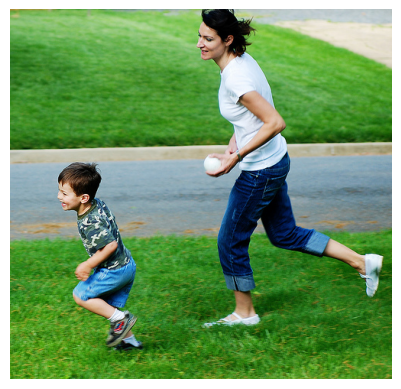

Image: 2854207034_1f00555703.jpg
Caption: two men are playing soccer
BLEU-4: 0.0000


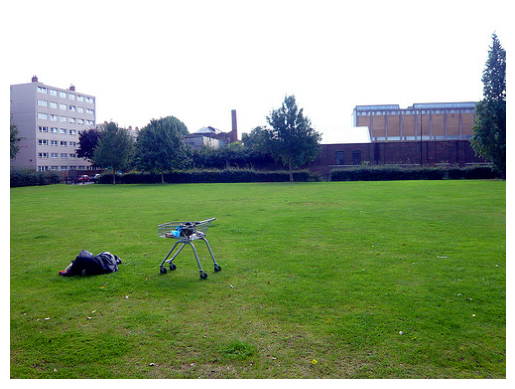

Image: 3115174046_9e96b9ce47.jpg
Caption: man skateboarding
BLEU-4: 0.0000


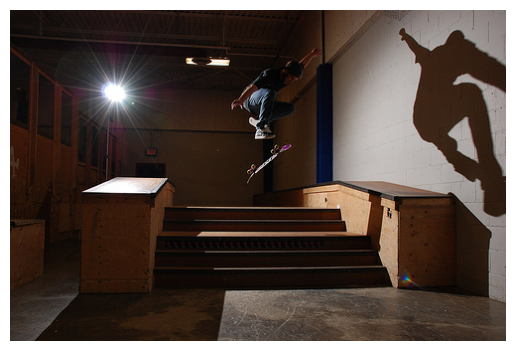

In [ ]:
def summarize_scores(results):
    bleu1_scores = [r[2] for r in results]
    bleu2_scores = [r[3] for r in results]
    bleu3_scores = [r[4] for r in results]
    bleu4_scores = [r[5] for r in results]
    meteor_scores = [r[6] for r in results]

    print("Average BLEU-1: {:.4f}".format(np.mean(bleu1_scores)))
    print("Average BLEU-2: {:.4f}".format(np.mean(bleu2_scores)))
    print("Average BLEU-3: {:.4f}".format(np.mean(bleu3_scores)))
    print("Average BLEU-4: {:.4f}".format(np.mean(bleu4_scores)))
    print("Average METEOR: {:.4f}".format(np.mean(meteor_scores)))



summarize_scores(results)
print("\n")

image_dir = "dataset/Flicker8k_Dataset/"
# Top 5 by BLEU-4
sorted_by_bleu4 = sorted(results, key=lambda x: x[5], reverse=True)
print(" Top 5 Captions by BLEU-4:\n")
for r in sorted_by_bleu4[:5]:
    print(f"Image: {r[0]}")
    print(f"Caption: {r[1]}")
    print(f"BLEU-4: {r[5]:.4f}")
    display_image(os.path.join(image_dir, r[0]))


# Bottom 5 by METEOR

print("\n Bottom 5 Captions by BLEU-4:\n")
sorted_by_bleu4 = sorted(results, key=lambda x: x[5])
for r in sorted_by_bleu4[:5]:
    print(f"Image: {r[0]}")
    print(f"Caption: {r[1]}")
    print(f"BLEU-4: {r[5]:.4f}")
    display_image(os.path.join(image_dir, r[0]))









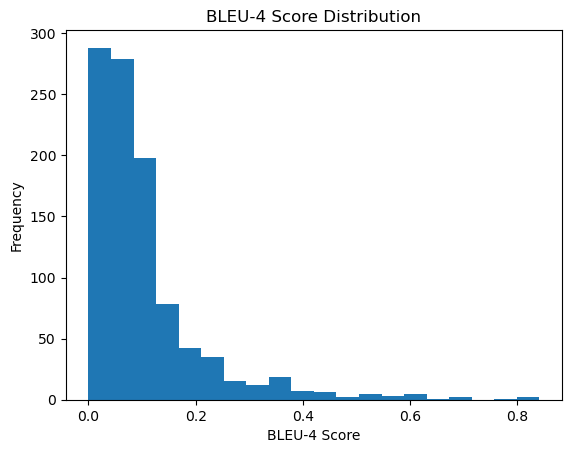

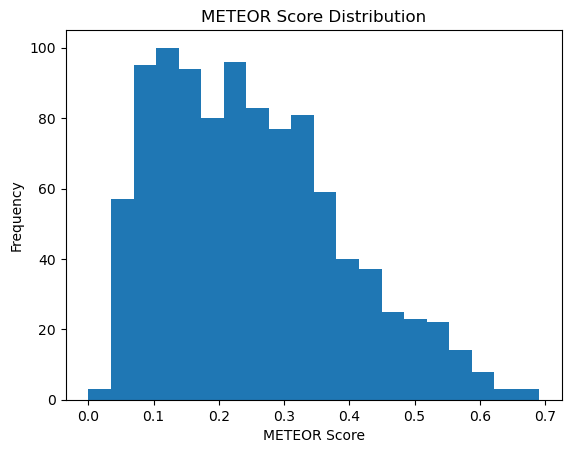

In [55]:
import matplotlib.pyplot as plt

bleu4 = [r[5] for r in results]
meteor = [r[6] for r in results]

plt.hist(bleu4, bins=20)
plt.title("BLEU-4 Score Distribution")
plt.xlabel("BLEU-4 Score")
plt.ylabel("Frequency")
plt.show()

plt.hist(meteor, bins=20)
plt.title("METEOR Score Distribution")
plt.xlabel("METEOR Score")
plt.ylabel("Frequency")
plt.show()


## Testing gradio

In [ ]:
import sqlite3
import numpy as np
import torch
import pickle
from PIL import Image
from io import BytesIO
from sklearn.metrics.pairwise import cosine_similarity
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import ViTFeatureExtractor, ViTModel

tokenizer = pickle.load(open("tokenizer.p", "rb"))
max_length = 32
caption_model = load_model("vit_transformer_best.h5", custom_objects={"PositionalEncoding": PositionalEncoding})
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

DB_FILE = "images.db"

def init_db():
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS images (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                image BLOB NOT NULL,
                caption TEXT NOT NULL,
                embedding BLOB NOT NULL
            )
        ''')
        conn.commit()

init_db()

def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = feature_extractor(images=image, return_tensors="pt")
    with torch.no_grad():
        vit_features = vit_model(**inputs).last_hidden_state.mean(dim=1)
    photo = vit_features.reshape(1, 768).numpy()
    photo_norm = photo / np.linalg.norm(photo)
    caption = generate_caption_beam(caption_model, tokenizer, photo_norm, max_length, 3)
    saveImageDesc(image_path, caption, photo_norm.squeeze())
    return caption

def saveImageDesc(img_path, caption, embedding):
    img = Image.open(img_path)
    img_bytes = BytesIO()
    img.save(img_bytes, format="PNG")
    img_data = img_bytes.getvalue()
    emb_blob = pickle.dumps(embedding)
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute("INSERT INTO images (image, caption, embedding) VALUES (?, ?, ?)", 
                       (img_data, caption, emb_blob))
        conn.commit()

def image_to_image_search(query_image, threshold=0.80):
    if isinstance(query_image, str):
        query_img = Image.open(query_image).convert("RGB")
    elif isinstance(query_image, Image.Image):
        query_img = query_image.convert("RGB")
    else:
        raise ValueError("Invalid input: must be a file path or a PIL.Image")

    inputs = feature_extractor(images=query_img, return_tensors="pt")
    with torch.no_grad():
        query_embedding = vit_model(**inputs).last_hidden_state.mean(dim=1).squeeze().numpy()
        query_embedding /= np.linalg.norm(query_embedding)

    results = []
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT image, caption, embedding FROM images")
        for img_data, caption, emb_blob in cursor.fetchall():
            stored_embedding = pickle.loads(emb_blob)
            stored_embedding /= np.linalg.norm(stored_embedding)
            sim = cosine_similarity([query_embedding], [stored_embedding])[0][0]
            if sim >= threshold:
                results.append((sim, img_data, caption))

    results.sort(reverse=True, key=lambda x: x[0])
    top_results = results[:5]

    display_images = []
    for sim, img_bytes, caption in top_results:
        img = Image.open(BytesIO(img_bytes))
        caption_with_score = f"Sim: {sim:.2f} | {caption}"
        display_images.append((img, caption_with_score))

    return display_images

def search_images(keyword):
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT image FROM images WHERE caption LIKE ?", ('%' + keyword + '%',))
        rows = cursor.fetchall()
    images = [Image.open(BytesIO(row[0])) for row in rows] if rows else []
    return gr.Gallery(images, columns=2)

caption_iface = gr.Interface(
    fn=generate_caption,
    inputs=gr.Image(type="filepath"),
    outputs="text",
    title="Image Caption Generator",
    description="Upload an image to generate a caption and store it locally."
)

search_text_iface = gr.Interface(
    fn=search_images,
    inputs="text",
    outputs=gr.Gallery(),
    title="Search Images by Text",
    description="Search images based on their generated captions."
)

search_image_iface = gr.Interface(
    fn=image_to_image_search,
    inputs=[
        gr.Image(type="filepath", label="Query Image"),
        gr.Slider(0.0, 1.0, step=0.01, value=0.80, label="Similarity Threshold")
    ],
    outputs=gr.Gallery(),
    title="Search Images by Image",
    description="Upload an image and filter similar results by cosine similarity."
)

gr.TabbedInterface(
    [caption_iface, search_text_iface, search_image_iface],
    ["Generate Caption", "Search by Text", "Search by Image"]
).launch()


/Users/abhinandanvijan/anaconda3/lib/python3.11/site-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


Running on local URL:  http://127.0.0.1:7863

To create a public link, set `share=True` in `launch()`.


IMPORTANT: You are using gradio version 4.36.1, however version 4.44.1 is available, please upgrade.
--------
IMPORTANT: You are using gradio version 4.36.1, however version 4.44.1 is available, please upgrade.
--------
IMPORTANT: You are using gradio version 4.36.1, however version 4.44.1 is available, please upgrade.
--------
IMPORTANT: You are using gradio version 4.36.1, however version 4.44.1 is available, please upgrade.
--------
